# Defining Churn

The dataset has no churn column, so we build one:

- A household has churned if it made **no purchase in the 28 days following a cutoff point T**.

### The trap

The approach of having label churn over the last 28 days (684-711) and
build features from the full history (1-711) silently breaks.
Recency measured at day 711 gives `recency > 28 -> churn = 1` with no exceptions.
The feature *is* the label. The model scores near-perfect AUC and has
learned nothing. This is **data leakage**. Spend and purchase counts are
contaminated the same way, more subtly.

### The fix: two non-overlapping windows

    days 1 ................ 683 | 684 ......... 711
    +-- observation window -----+ +-- outcome window --+
            FEATURES only              LABEL only
                              T = 683

Recency is now measured at T, and the identity breaks:

| household | last purchase <= 683 | recency_at_T | bought in 684-711? | churn |
|-----------|----------------------|--------------|--------------------|-------|
| 1042      | day 660              | 23           | no                 | 1     |
| 2088      | day 660              | 23           | yes (day 690)      | 0     |

Same feature, different labels. Recency stays a strong signal, but it is
now a clue rather than the answer.

**Working rule:** every feature aggregation carries `DAY <= 683`. Any
aggregation without it is assumed to leak until proven otherwise.

**Eligible population:** only households with at least one purchase in
the 90 days before T (594-683). Anyone quieter than that left long ago
and isn't churning now.

**Note:** T splits *time* to build a clean label. The train/test split
comes later and splits *households*. Different cuts, different purposes.

# Data prep

Initial exploration of the **8 raw datasets available to this project**.
The goal here is to load each table, inspect its structure (shape, keys, nulls, data types), apply light cleaning and make them ready for exploration

In [2]:
# Checking import happened correctly
import glob
hits = glob.glob("/kaggle/input/**/*.csv", recursive=True)
print(f"{len(hits)} CSV files found:")
for h in hits:
    print(" ", h)

8 CSV files found:
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/campaign_table.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/causal_data.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/coupon.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/campaign_desc.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/product.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/transaction_data.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/hh_demographic.csv
  /kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey/coupon_redempt.csv


In [3]:
# Define the path to access the databases
from pathlib import Path
RAW_PATH = Path("/kaggle/input/datasets/frtgnn/dunnhumby-the-complete-journey")

## Transactions data

**Data quality checks**

Before transforming the table, confirm that the assumed composite key (`household_key`, `BASKET_ID`, `PRODUCT_ID`) is actually unique, and check for missing values that would need to be handled.

In [4]:
# Load the transactions table and check its shape and first rows
import pandas as pd

transactions = pd.read_csv(RAW_PATH / "transaction_data.csv")
print(transactions.shape)
transactions.head()

(2595732, 12)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [5]:
# Map the interval of days
print(transactions["DAY"].min(), transactions["DAY"].max())

# Map the Number of HH.
print(transactions["household_key"].nunique())

1 711
2500


In [6]:
# Verify that household_key + BASKET_ID + PRODUCT_ID together form a unique key (no duplicate rows for the same product in the same basket)
key_cols = ["household_key", "BASKET_ID", "PRODUCT_ID"]
print(transactions.shape[0])
print(transactions.duplicated(subset=key_cols).sum())

2595732
0


In [7]:
# Check for missing values in every column
transactions.isnull().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

## Product Table
Product catalog with department, brand and commodity/sub-commodity descriptions, keyed by PRODUCT_ID.

In [8]:
# Load the product table and confirm PRODUCT_ID is a unique key
product = pd.read_csv(RAW_PATH / "product.csv")
print(product.shape)
# Confirming Key
print(product["PRODUCT_ID"].duplicated().sum())
product.head()

(92353, 7)
0


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


## Household demographics
Household-level demographic attributes (age, income, marital status, household composition, etc.), keyed by household_key.

In [9]:
# Load the household demographic table and confirm there are no fully duplicated rows
hh_demographic = pd.read_csv(RAW_PATH / "hh_demographic.csv")
print(hh_demographic.shape)
print(hh_demographic["household_key"].duplicated().sum())
hh_demographic.head()

(801, 8)
0


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [10]:
# Check for missing values in every column
hh_demographic.isnull().sum()

AGE_DESC               0
MARITAL_STATUS_CODE    0
INCOME_DESC            0
HOMEOWNER_DESC         0
HH_COMP_DESC           0
HOUSEHOLD_SIZE_DESC    0
KID_CATEGORY_DESC      0
household_key          0
dtype: int64

In [11]:
for c in hh_demographic.select_dtypes("object"):
    print(c, hh_demographic[c].value_counts().to_dict())

AGE_DESC {'45-54': 288, '35-44': 194, '25-34': 142, '65+': 72, '55-64': 59, '19-24': 46}
MARITAL_STATUS_CODE {'U': 344, 'A': 340, 'B': 117}
INCOME_DESC {'50-74K': 192, '35-49K': 172, '75-99K': 96, '25-34K': 77, '15-24K': 74, 'Under 15K': 61, '125-149K': 38, '100-124K': 34, '150-174K': 30, '250K+': 11, '175-199K': 11, '200-249K': 5}
HOMEOWNER_DESC {'Homeowner': 504, 'Unknown': 233, 'Renter': 42, 'Probable Renter': 11, 'Probable Owner': 11}
HH_COMP_DESC {'2 Adults No Kids': 255, '2 Adults Kids': 187, 'Single Female': 144, 'Single Male': 95, 'Unknown': 73, '1 Adult Kids': 47}
HOUSEHOLD_SIZE_DESC {'2': 318, '1': 255, '3': 109, '5+': 66, '4': 53}
KID_CATEGORY_DESC {'None/Unknown': 558, '1': 114, '3+': 69, '2': 60}


**Inferring missing kid category**

`KID_CATEGORY_DESC` is `'None/Unknown'` for a large share of households, which conflates two very different cases: households that genuinely have no kids, and households where the number of kids simply wasn't captured. Household composition (`HH_COMP_DESC`) lets us recover some of that signal — categories like `'2 Adults No Kids'`, `'Single Female'` and `'Single Male'` imply no kids even when `KID_CATEGORY_DESC` doesn't say so explicitly. Use this to build a cleaner `KID_CATEGORY_INFERRED` column.

In [12]:
pd.crosstab(hh_demographic["HH_COMP_DESC"], hh_demographic["KID_CATEGORY_DESC"])

KID_CATEGORY_DESC,1,2,3+,None/Unknown
HH_COMP_DESC,,,,
1 Adult Kids,20,14,13,0
2 Adults Kids,88,46,53,0
2 Adults No Kids,0,0,0,255
Single Female,0,0,0,144
Single Male,0,0,0,95
Unknown,6,0,3,64


In [13]:
# KID_CATEGORY_DESC is 'None/Unknown' for many households where we can still infer there are no kids
# from HH_COMP_DESC (e.g. '2 Adults No Kids', 'Single Female', 'Single Male').
# Build a cleaner KID_CATEGORY_INFERRED column: keep the original value when it is known,
# set it to 'None' when the household composition implies no kids, otherwise leave it as 'Unknown'.
import numpy as np

no_kids_categories = ["2 Adults No Kids", "Single Female", "Single Male"]

hh_demographic["KID_CATEGORY_INFERRED"] = np.select(
    [
        hh_demographic["KID_CATEGORY_DESC"] != "None/Unknown",
        hh_demographic["HH_COMP_DESC"].isin(no_kids_categories),
    ],
    [
        hh_demographic["KID_CATEGORY_DESC"],
        "None",
    ],
    default="Unknown",
)

In [14]:
pd.crosstab(hh_demographic["HH_COMP_DESC"], hh_demographic["KID_CATEGORY_INFERRED"])

KID_CATEGORY_INFERRED,1,2,3+,None,Unknown
HH_COMP_DESC,,,,,
1 Adult Kids,20,14,13,0,0
2 Adults Kids,88,46,53,0,0
2 Adults No Kids,0,0,0,255,0
Single Female,0,0,0,144,0
Single Male,0,0,0,95,0
Unknown,6,0,3,0,64


In [15]:
# Check the resulting distribution of the inferred kid category
hh_demographic["KID_CATEGORY_INFERRED"].value_counts()

KID_CATEGORY_INFERRED
None       494
1          114
3+          69
Unknown     64
2           60
Name: count, dtype: int64

### Referential integrity between tables

In [16]:
# transactions -> product
products_not_on_master = set(transactions["PRODUCT_ID"].unique()) - set(product["PRODUCT_ID"].unique())

# transactions -> hh_demographic
homes_not_on_master = set(transactions["household_key"].unique()) - set(hh_demographic["household_key"].unique())

print(f"Products from Transaction not on Product Table: {len(products_not_on_master)}")
print(f"Houses from Transaction not on Houses Table: {len(homes_not_on_master)}")

Products from Transaction not on Product Table: 0
Houses from Transaction not on Houses Table: 1699


**Referential integrity results**

Every `PRODUCT_ID` in transactions exists in the product catalog so the join
is safe with no orphan products.

Households are a different story: 1,699 of the 2,500 households that
transact have no row in `hh_demographic`. Since the table has 801 rows,
this also means there are no orphan demographic records, every
demographic row maps to a real household. Coverage is 32%.

Combined with the `'U'` / `'Unknown'` rates seen above, `MARITAL_STATUS_CODE`
is effectively populated for around 18% of the customer base. Demographic
attributes are therefore treated as optional enrichment, not as a core
feature block for the first model.

# Data Exploration

## Checking Time Series

We'll map any patterns of behaviours that might interfer in the churn analysis

<Axes: title={'center': 'Distinct baskets per day'}, xlabel='DAY'>

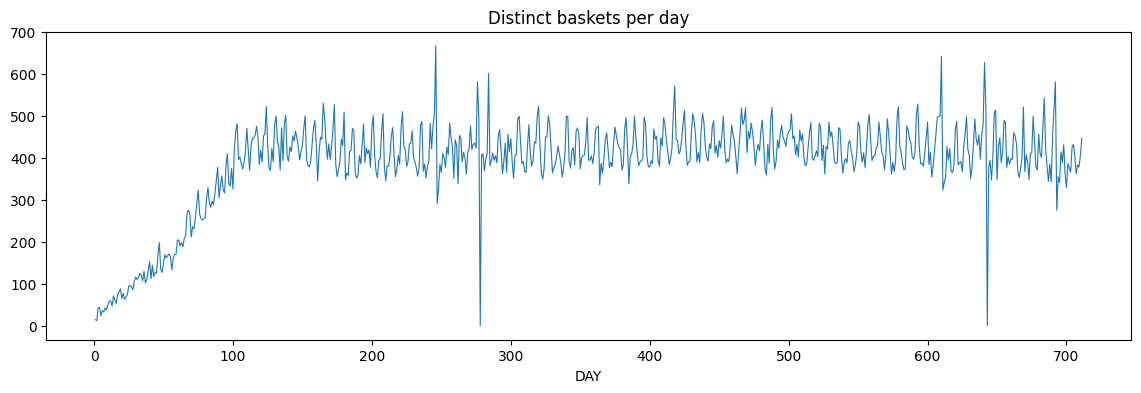

In [17]:
daily = transactions.groupby("DAY")["BASKET_ID"].nunique()
daily.plot(figsize=(14,4), lw=0.8, title="Distinct baskets per day")

In [18]:
first_day = transactions.groupby("household_key")["DAY"].min()
first_day.describe()

count    2500.000000
mean       65.941200
std        39.152355
min         1.000000
25%        36.000000
50%        69.000000
75%        95.000000
max       671.000000
Name: DAY, dtype: float64

In [19]:
first_day = transactions.groupby("household_key")["DAY"].min()
print((first_day > 594).sum())   
print((first_day > 500).sum())   

2
2


### Time series sanity check — conclusions

Before building the label, the daily transaction volume was inspected to
confirm the outcome window (days 684-711) is usable.

**The outcome window is clean.** Days 650-711 sit in the same 350-500
baskets/day band as the rest of the series, with the same weekly
seasonality. There is no truncation or structural decline at the end of
the data, so a household with no purchase in 684-711 is genuinely absent,
not an artefact of collection stopping.

**The panel ramps up over the first ~95 days.** Volume climbs from ~20 to
~450 baskets/day before flattening. This is households entering the panel
progressively, not business growth. Confirmed by the distribution of each
household's first observed day:

Half the households only appear after day 69. A household absent on day 40
was not inactive, it was not being observed.

*Consequence:* features must be computed over **windows anchored at T**
(last 28 / 90 / 180 days before day 683) rather than over full history.
Whole-history aggregates such as "total visits" would partly measure
length of panel membership instead of behaviour.

**Late entrants are negligible.** Only 2 of 2,500 households first appear
after day 500. No exclusion rule is warranted for 0.08% of the base; they
are handled by a `tenure_days = 683 - first_day` feature instead.

**Confirmed:** `DAY` runs 1-711, so the cutoff is fixed at **T = 683**.

## Building the label

    observation : days 1-683    (features only)
    outcome     : days 684-711  (label only, 28 days)

T = 683 is forced by the data: outcome must be 28 days, data ends at 711.

**Eligible population**: at least one purchase in the 90 days before T
(days 594-683): **2,323 of 2,500**, removing 7.1%.

The 90-day threshold defines *who the question is asked about*, which is
separate from the 28-day definition of the event.

**Label**: `churn = 1` if no purchase in days 684-711.

**Consequences**: imbalance is 6.4:1, so no resampling; accuracy is
unusable (predicting "nobody leaves" scores 84.4%), so PR-AUC is the
primary metric. With ~290 positives in training, flexible models will
memorise and model selection must come from CV variance, not a single
test-set comparison.

### Segregating eligeble table

In [20]:
T = 683
OUTCOME_DAYS = 28
ELIGIBILITY_DAYS = 90

#Eligible: At least one purchase in the 90 days before T
eligible = (
    transactions.loc[transactions["DAY"].between(T - ELIGIBILITY_DAYS + 1, T), "household_key"]
    .unique()
)

eligible = pd.Series(sorted(eligible), name ="household_key")

print(f"households in transactions : {transactions['household_key'].nunique():,}")
print(f"eligible at T={T}          : {len(eligible):,}")

households in transactions : 2,500
eligible at T=683          : 2,323


### Calculating Churn

In [21]:
# WHo bought in the outcome window?
buyers_in_outcome = set(
    transactions.loc[transactions["DAY"].between(T+1, T + OUTCOME_DAYS), "household_key"]
)

households = pd.DataFrame({"household_key": eligible})
households["churn"] = (~households["household_key"].isin(buyers_in_outcome)).astype(int)

print(households["churn"].value_counts())
print(f"\nchurn rate: {households['churn'].mean():.1%}")

churn
0    1960
1     363
Name: count, dtype: int64

churn rate: 15.6%


# Test and Training Split

The split is on **households**, not on time as the time split (T = 683) was
already done when building the label. Two different cuts, two purposes:
T protects against predicting the present with the present, this one
protects against memorising instead of learning.

Stratified on `churn`: with only 363 positives, an unstratified draw can
easily land 14% on one side and 18% on the other by chance alone.
`random_state` fixed so the split is reproducible.

Test size is 20%, leaving ~73 positives for the final evaluation. That is
small, and it is the ceiling this dataset allows as a larger test set would
starve an already-thin training positive class.


**Model selection comes from cross-validation on the training set, not fromcomparing test scores.**


**Rule from here on:** `test_hh` is not opened, plotted or described until
the final evaluation. All EDA and all model selection happen on `train_hh`.

In [22]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

train_hh, test_hh = train_test_split(
    households,
    test_size=0.20,
    stratify=households["churn"],
    random_state=RANDOM_STATE
)

print(f"train : {len(train_hh):>5,}  churn {train_hh['churn'].mean():.1%}  ({train_hh['churn'].sum()} positives)")
print(f"test  : {len(test_hh):>5,}  churn {test_hh['churn'].mean():.1%}  ({test_hh['churn'].sum()} positives)")

train : 1,858  churn 15.6%  (290 positives)
test  :   465  churn 15.7%  (73 positives)


# Building Features

In [31]:
def build_features(household_keys, transactions, cutoff=683):
    """
    Aggregate transactions into one row per household.
    Only data up to `cutoff` is used so the outcome window never enters here.
    """

    household_keys = pd.Index(household_keys, name="household_key")

    tx = transactions[
        (transactions["DAY"]<=cutoff)
        & (transactions["household_key"].isin(household_keys))
    ]

    g = tx.groupby("household_key")
    feats = pd.DataFrame(index=household_keys)
    feats["recency"] = cutoff - g["DAY"].max()
    feats["tenure_days"] = cutoff - g["DAY"].min()

    for w in (90, 180):
        win = tx[tx["DAY"] > cutoff - w].groupby("household_key")
        feats[f"visits_{w}d"] = win["BASKET_ID"].nunique()

    win90 = tx[tx["DAY"] > cutoff - 90].groupby("household_key")
    feats["spend_90d"]             = win90["SALES_VALUE"].sum()
    feats["distinct_products_90d"] = win90["PRODUCT_ID"].nunique()

    # counts and sums are genuinely zero when a window is empty
    count_cols = ["visits_90d", "visits_180d", "spend_90d",
                  "distinct_products_90d"]
    feats[count_cols] = feats[count_cols].fillna(0)

    # derived: average basket size, guarding against division by zero
    feats["basket_size_90d"] = (
        feats["distinct_products_90d"] / feats["visits_90d"].replace(0, np.nan)
    ).fillna(0)

    return feats

In [32]:
X_train = build_features(train_hh["household_key"], transactions)
X_train.head()


,recency,tenure_days,visits_90d,visits_180d,spend_90d,distinct_products_90d,basket_size_90d
household_key,,,,,,,
2392,1,671,13,25,317.92,96,7.384615
671,6,606,19,35,629.61,84,4.421053
887,11,678,8,13,128.53,58,7.250000
2468,21,608,7,14,57.08,37,5.285714
1963,2,612,6,11,416.44,143,23.833333


In [33]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,1858.0,12.056512,17.422914,0.000000,1.000000,5.000000,14.000000,89.0
tenure_days,1858.0,616.874058,38.420473,12.000000,588.000000,614.000000,647.000000,682.0
visits_90d,1858.0,16.226588,17.148495,1.000000,5.000000,11.000000,21.000000,168.0
visits_180d,1858.0,32.517223,34.345249,1.000000,11.000000,22.000000,43.000000,355.0
spend_90d,1858.0,508.839909,557.809596,0.690000,131.160000,317.215000,692.010000,6783.3
distinct_products_90d,1858.0,119.560818,106.376450,1.000000,39.000000,89.000000,173.000000,747.0
basket_size_90d,1858.0,9.075946,6.941318,0.333333,4.591176,7.422222,11.453297,72.0


In [35]:
y_train = train_hh.set_index("household_key")["churn"].reindex(X_train.index)